In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)



In [4]:
print(X.describe().to_string())

       mean radius  mean texture  mean perimeter    mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter   worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension
count   569.000000    569.000000      569.000000   569.000000       569.000000        569.000000      569.000000           569.000000     569.000000              569.000000    569.000000     569.000000       569.000000  569.000000        569.000000         569.000000       569.000000            569.000000      569.000000               569.000000    569.000000     569.000000       569.000000   569.000000        569.000000         569.000000       569.000000            569.

In [5]:
X.mean()

mean radius                 14.127292
mean texture                19.289649
mean perimeter              91.969033
mean area                  654.889104
mean smoothness              0.096360
mean compactness             0.104341
mean concavity               0.088799
mean concave points          0.048919
mean symmetry                0.181162
mean fractal dimension       0.062798
radius error                 0.405172
texture error                1.216853
perimeter error              2.866059
area error                  40.337079
smoothness error             0.007041
compactness error            0.025478
concavity error              0.031894
concave points error         0.011796
symmetry error               0.020542
fractal dimension error      0.003795
worst radius                16.269190
worst texture               25.677223
worst perimeter            107.261213
worst area                 880.583128
worst smoothness             0.132369
worst compactness            0.254265
worst concav

In [6]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 455 samples
Testing set size: 114 samples
Training set size: 483 samples
Testing set size: 86 samples


In [7]:
# Create a list of k values (neighbors) for KNN
#k_values = [1, 5, 11, 15, 21]
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
# Train KNN models with different k values and store the results
knn_results = {}
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred_knn = knn_model.predict(X_test)
    knn_results[k] = {
        'model': knn_model,
        'y_pred': y_pred_knn,
        'accuracy': accuracy_score(y_test, y_pred_knn)
    }

In [8]:
# Create a list of radius values for RNN
radius_values = [350, 400, 450, 500, 550, 600]
# Train RNN models with different radius values and store the results
rnn_results = {}
for radius in radius_values:
    rnn_model = RadiusNeighborsClassifier(radius=radius)
    rnn_model.fit(X_train, y_train)
    y_pred_rnn = rnn_model.predict(X_test)
    rnn_results[radius] = {
        'model': rnn_model,
        'y_pred': y_pred_rnn,
        'accuracy': accuracy_score(y_test, y_pred_rnn)
    }

# Print the accuracy of KNN models
print("KNN Accuracy:")
for k, result in knn_results.items():
    print(f"K = {k}: {result['accuracy']:.2f}")
# Print the accuracy of RNN models
print("\nRNN Accuracy:")
for radius, result in rnn_results.items():
    print(f"Radius = {radius}: {result['accuracy']:.2f}")

KNN Accuracy:
K = 1: 0.92
K = 3: 0.92
K = 5: 0.93
K = 7: 0.94
K = 9: 0.94
K = 11: 0.98
K = 13: 0.98
K = 15: 0.98
K = 17: 0.97
K = 19: 0.97
K = 21: 0.97

RNN Accuracy:
Radius = 350: 0.93
Radius = 400: 0.93
Radius = 450: 0.93
Radius = 500: 0.90
Radius = 550: 0.90
Radius = 600: 0.90


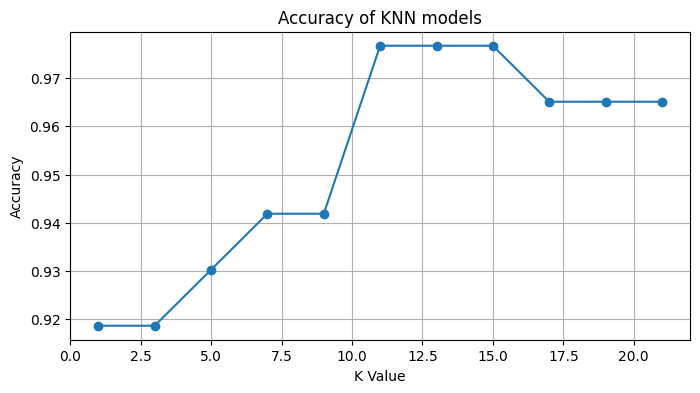

In [9]:
# Visualize the accuracy of KNN models
k_values = [k for k in knn_results.keys()]
k_accuracies = [result['accuracy'] for result in knn_results.values()]
plt.figure(figsize=(8, 4))
plt.plot(k_values, k_accuracies, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy of KNN models')
plt.grid(True)
plt.show()

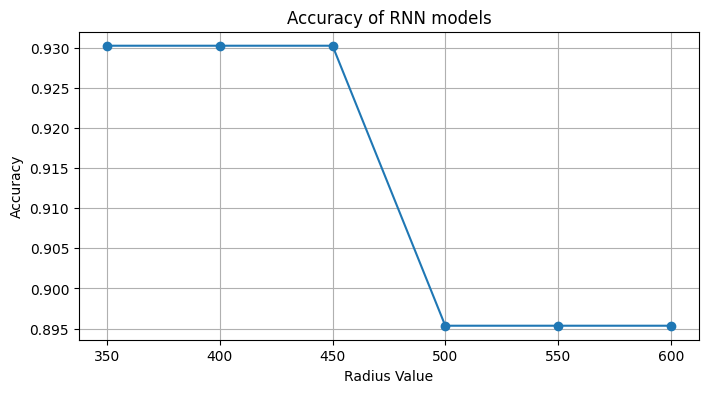

In [10]:
# Visualize the accuracy of RNN models
radius_values = [radius for radius in rnn_results.keys()]
radius_accuracies = [result['accuracy'] for result in rnn_results.values()]
plt.figure(figsize=(8, 4))
plt.plot(radius_values, radius_accuracies, marker='o')
plt.xlabel('Radius Value')
plt.ylabel('Accuracy')
plt.title('Accuracy of RNN models')
plt.grid(True)
plt.show()

In [11]:
#Case Study – Breast Cancer Classification Using Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [12]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a list of splitting criteria
splitting_criteria = ['entropy', 'gini']
# Create a list of max depth values
max_depth_values = range(1, 20, 2)
# Create an empty dictionary to store the results
results = {}
# Train Different Decision Tree models
for criterion in splitting_criteria:
    for max_depth in max_depth_values:
        dt_model = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth)
        dt_model.fit(X_train, y_train)
        y_pred = dt_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[(criterion, max_depth)] = {
            'model': dt_model,
            'accuracy': accuracy
        }

# Print the results of the classification
print("Results of Decision Tree Classification:")
for (criterion, max_depth), result in results.items():
    print(f"Criterion: {criterion}, Max Depth: {max_depth}, Accuracy: {result['accuracy']:.2f}")
    #print()

Results of Decision Tree Classification:
Criterion: entropy, Max Depth: 1, Accuracy: 0.89
Criterion: entropy, Max Depth: 3, Accuracy: 0.96
Criterion: entropy, Max Depth: 5, Accuracy: 0.95
Criterion: entropy, Max Depth: 7, Accuracy: 0.95
Criterion: entropy, Max Depth: 9, Accuracy: 0.96
Criterion: entropy, Max Depth: 11, Accuracy: 0.95
Criterion: entropy, Max Depth: 13, Accuracy: 0.95
Criterion: entropy, Max Depth: 15, Accuracy: 0.95
Criterion: entropy, Max Depth: 17, Accuracy: 0.96
Criterion: entropy, Max Depth: 19, Accuracy: 0.95
Criterion: gini, Max Depth: 1, Accuracy: 0.89
Criterion: gini, Max Depth: 3, Accuracy: 0.94
Criterion: gini, Max Depth: 5, Accuracy: 0.94
Criterion: gini, Max Depth: 7, Accuracy: 0.95
Criterion: gini, Max Depth: 9, Accuracy: 0.94
Criterion: gini, Max Depth: 11, Accuracy: 0.94
Criterion: gini, Max Depth: 13, Accuracy: 0.94
Criterion: gini, Max Depth: 15, Accuracy: 0.94
Criterion: gini, Max Depth: 17, Accuracy: 0.94
Criterion: gini, Max Depth: 19, Accuracy: 0.94

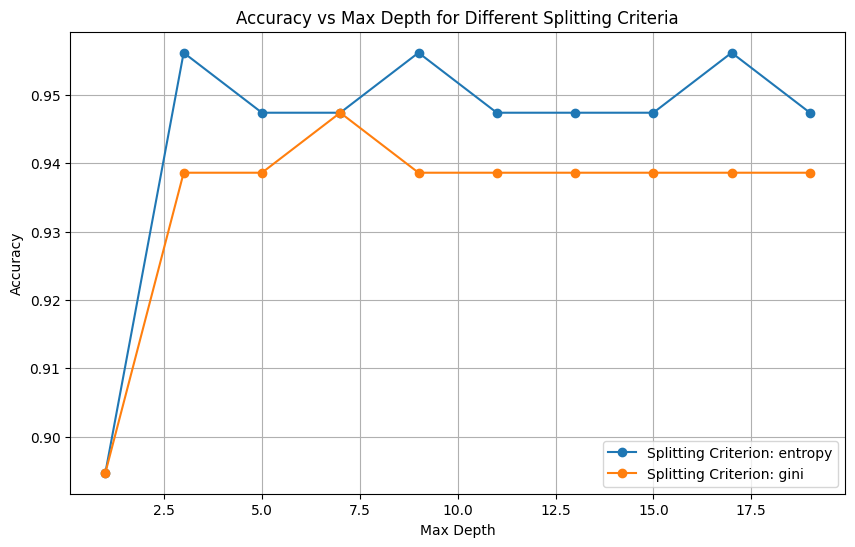

In [13]:
plt.figure(figsize=(10, 6))
for criterion in splitting_criteria:
    accuracies = [result['accuracy'] for (c, md),
    result in results.items() if c == criterion]
    plt.plot(max_depth_values, accuracies, marker='o', label=f'Splitting Criterion: {criterion}')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Max Depth for Different Splitting Criteria')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
#Case Study – Breast Cancer Classification Using SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Create a list of regularization parameter values
C_values = [0.01, 0.1, 1, 10, 100]
# Create an empty dictionary to store the results
results = {}
# Train SVM models with different C values
for C in C_values:
    svm_model = SVC(C=C, kernel='sigmoid')
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[C] = {
        'model': svm_model,
        'accuracy': accuracy
    }

In [16]:
# Print the results of the classification
print("Results of SVM Classification:")
for C, result in results.items():
    print(f"C = {C}, Accuracy: {result['accuracy']:.4f}")

Results of SVM Classification:
C = 0.01, Accuracy: 0.6228
C = 0.1, Accuracy: 0.6228
C = 1, Accuracy: 0.4649
C = 10, Accuracy: 0.3947
C = 100, Accuracy: 0.9123


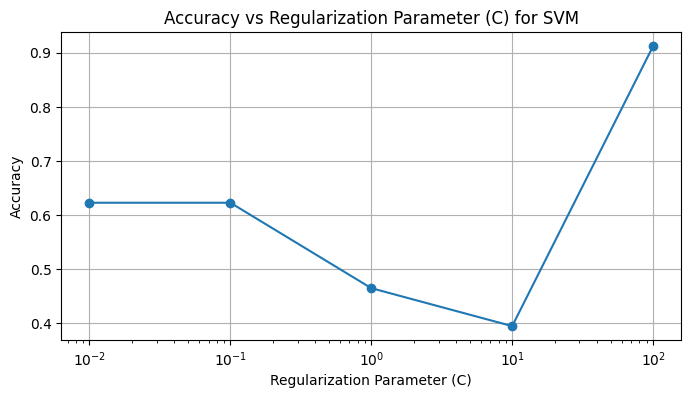

In [17]:
# Visualize the accuracy vs regularization parameter (C)
accuracies = [result['accuracy'] for C, result in results.items()]
plt.figure(figsize=(8, 4))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Regularization Parameter (C) for SVM')
plt.grid(True)
plt.show()

In [18]:
#Case Study – Breast Cancer Classification Using Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create the Naive Bayes model
nb_model = GaussianNB()
# Train the model
nb_model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = nb_model.predict(X_test)
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy of the Naive Bayes model
print("Accuracy of Naive Bayes model:", accuracy)

Accuracy of Naive Bayes model: 0.9736842105263158


In [20]:
#Case Study – Breast Cancer Classification Using Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create a list of regularization parameter values
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
# Create an empty dictionary to store the results
results = {}
# Train Logistic Regression models with different C values
for C in C_values:
    lr_model = LogisticRegression(C=C, random_state=42, max_iter=20000) #change 2000 to 20000
    lr_model.fit(X_train, y_train)
    y_pred = lr_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[C] = {
    'model': lr_model,
    'accuracy': accuracy
}
    
# Print the results of the classification
print("Results of Logistic Regression Classification:")
for C, result in results.items():
    print(f"C = {C}, Accuracy: {result['accuracy']:.4f}")

Results of Logistic Regression Classification:
C = 0.001, Accuracy: 0.9649
C = 0.01, Accuracy: 0.9649
C = 0.1, Accuracy: 0.9649
C = 1, Accuracy: 0.9561
C = 10, Accuracy: 0.9561
C = 100, Accuracy: 0.9561
C = 1000, Accuracy: 0.9825


/Users/maxy/Desktop/AU/Sem 5/CSX.ITX.4202_DataMining/Python_DataSets.Codes/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 12517 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
